# TNG Workshop — Loading Simulation Data

In this session, we will explore how to load and inspect data from the IllustrisTNG simulations using the groupcat tools.
The goal is to understand how to select different simulations, access subhalo and halo catalogues, and work with basic metadata such as the snapshot number–redshift relation.

In [2]:
import h5py
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import struct
from scipy.optimize import curve_fit
import time
import illustris_python as il
import astropy


Load functions from astro_utils

In [3]:
import sys
sys.path.append('/home/tnguser/TNGCluster')

from astro_utils.function_coord import *
from astro_utils.function_plot import *
from astro_utils.spherical_coord import *
from astro_utils.utils_astro import *
from astro_utils.IllustrisTNG_functions.Get_Particles_snap import *

from astropy.cosmology import FlatLambdaCDM, z_at_value
from astropy import units  as u
from scipy.stats import binned_statistic
from collections import OrderedDict


 What kind of functions are in astro_utils

In [4]:
import inspect
import astro_utils.function_coord as fc
import astro_utils.function_plot as fp
import astro_utils.spherical_coord as sc
import astro_utils.utils_astro as ua
import astro_utils.IllustrisTNG_functions.Get_Particles_snap as gps

modules = [fc, fp, sc, ua, gps]

for m in modules:
    funcs = [name for name, obj in inspect.getmembers(m, inspect.isfunction)]
    print(f"\n📘 Functions in {m.__name__}:")
    for f in funcs:
        print("  •", f)


📘 Functions in astro_utils.function_coord:
  • Moster2018
  • Moster2018_4
  • Moster2018_8
  • NFW
  • calc_densidad
  • defcaustic
  • einas
  • epsilon
  • fit_Sersic_fun
  • get_optical_radius
  • get_optical_radius_cut_DeRossi
  • mass_profile
  • profile_r_mass
  • shape_halo_ep
  • shape_halo_vector
  • shrinking_sphere
  • shrinking_sphere_old
  • sigma_SMHM
  • velocity_dispersion

📘 Functions in astro_utils.function_plot:
  • density_plot
  • double_scatter_plot
  • galplot
  • plotcaustic
  • plothist
  • scatter_plot

📘 Functions in astro_utils.spherical_coord:
  • appendSpherical_np
  • cartesian_to_spherical
  • convert_angle_to_0_2pi_interval
  • get_rotation_matrix
  • rotador_mio
  • rotation_matrix
  • rotation_matrix_from_vectors

📘 Functions in astro_utils.utils_astro:
  • annotation_line
  • calc_J
  • colored_line
  • find_nearest
  • integrated_time
  • legend_without_duplicate_labels
  • moving_median
  • moving_percentile25
  • moving_percentile75
  • profile_

# Plot all Galaxies from TNG-Cluster (not all have high res)

In [5]:
basePath_tngcluster = '/home/tnguser/sims.TNG/TNG-Cluster/output'
basePath_tng50 = '/home/tnguser/sims.TNG/TNG50-1/output'
basePath_tng100 = '/home/tnguser/sims.TNG/TNG100-1/output'
basePath_tng300 = '/home/tnguser/sims.TNG/TNG300-1/output'

base_out = '/home/tnguser/TNGCluster/'

G=43007.1/1.e10     # Constante de Newton en unidades de masas solares
#mass_DM_particle = 3.07367708626464e-05 # TNG50
#mass_DM_particle = 5.05574296e-04 # TNG100
mass_DM_particle = 0.00074374 # TNG300 + TNGCluster


Use groupcat load Subhalos and Halos

In [6]:

snap_number=99
hh = 0.6774
###########################
fields=['SubhaloMassInHalfRadType','SubhaloHalfmassRadType','SubhaloGasMetalFractionsHalfRad','SubhaloSFRinHalfRad']

subhalos_tng50 = il.groupcat.loadSubhalos(basePath_tngcluster,snap_number,fields=fields)

############### M_subhalos ########################
M_hm_gas = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][:,0])*1e10 / hh
M_hm_dm = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][:,1])*1e10 / hh
M_hm_star = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][:,4])*1e10 / hh

################# Metallicity Gas ####################

H_hm_gas = np.array(subhalos_tng50['SubhaloGasMetalFractionsHalfRad'][:,0])
O_hm_gas = np.array(subhalos_tng50['SubhaloGasMetalFractionsHalfRad'][:,4])

############### r_hm ########################

r_hm_gas = np.array(subhalos_tng50['SubhaloHalfmassRadType'][:,0])/ hh
r_hm_dm = np.array(subhalos_tng50['SubhaloHalfmassRadType'][:,1])/ hh
r_hm_star = np.array(subhalos_tng50['SubhaloHalfmassRadType'][:,4])/ hh

################ sSFR ######################

SFR_hm  = np.array(subhalos_tng50['SubhaloSFRinHalfRad'])


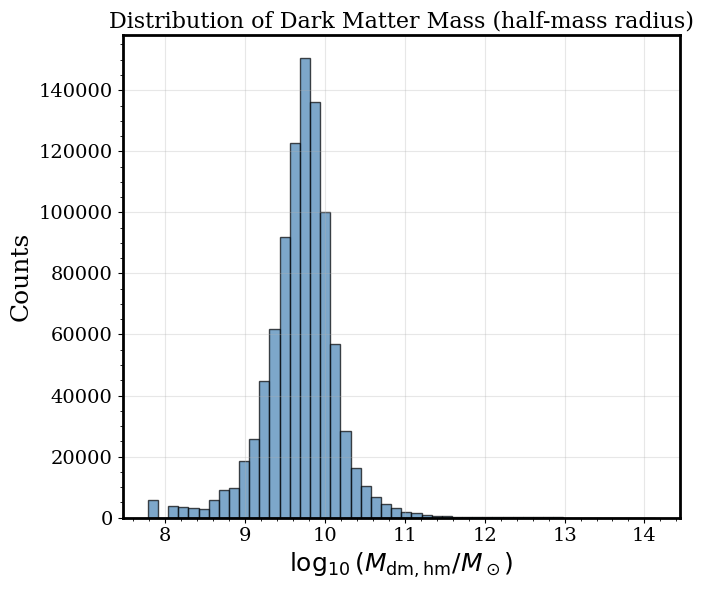

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7,6))

# Histogram of dark matter half-mass
ax.hist(
    np.log10(M_hm_dm[M_hm_dm > 0]),  # log10 scale, ignoring zeros
    bins=50,
    color='steelblue',
    alpha=0.7,
    edgecolor='black'
)

ax.set_xlabel(r'$\log_{10}(M_{\mathrm{dm,hm}} / M_\odot)$', fontsize=18)
ax.set_ylabel('Counts', fontsize=18)
ax.set_title('Distribution of Dark Matter Mass (half-mass radius)', fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=14)
ax.minorticks_on()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# General scale relations

/tmp/ipykernel_3260/3277430149.py:19: RuntimeWarning: divide by zero encountered in log10
  np.log10(SFR_hm[idx] / M_hm_star[idx]) + 9,
/tmp/ipykernel_3260/3277430149.py:36: RuntimeWarning: invalid value encountered in divide
  Metal_O_H = O_hm_gas / H_hm_gas


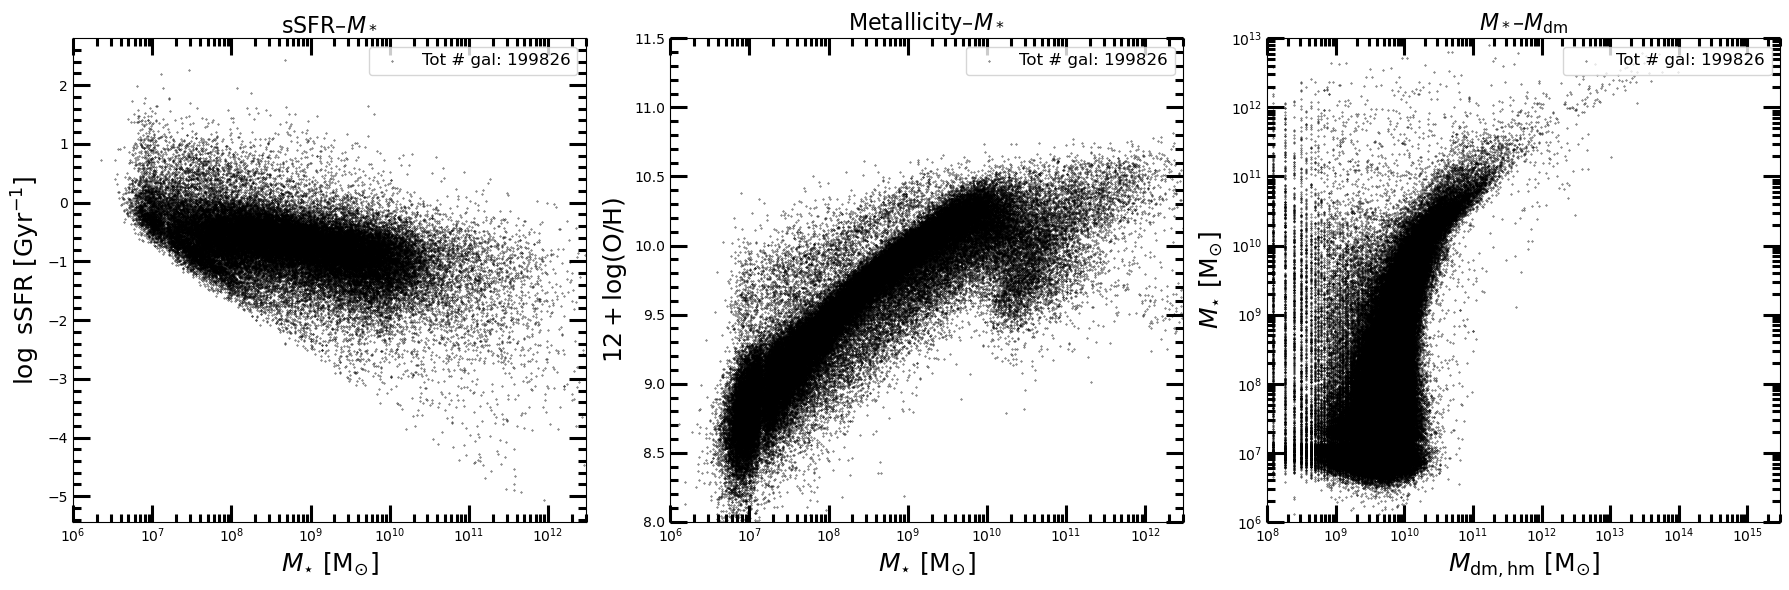

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sampling factor ---
frac = 0.2  # fraction of data to use (e.g. 0.2 = 20%)
idx = np.random.choice(np.where(M_hm_star > 0)[0],
                       size=int(frac * np.sum(M_hm_star > 0)),
                       replace=False)

# --- Create 1x3 subplot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plt.subplots_adjust(wspace=0.3)

#######################
# 1️⃣ sSFR–M_star
#######################
axes[0].scatter(
    M_hm_star[idx],
    np.log10(SFR_hm[idx] / M_hm_star[idx]) + 9,
    s=0.1, color='k',
    label=f"Tot # gal: {len(idx)}"
)
axes[0].set_xlabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[0].set_ylabel(r'$\log$ sSFR $\mathrm{[Gyr^{-1}]}$', fontsize=18)
axes[0].set_xscale("log")
axes[0].set_xlim(1e6, 3e12)
axes[0].minorticks_on()
axes[0].tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
axes[0].tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)
axes[0].legend(fontsize=12, loc='upper right')
axes[0].set_title("sSFR–$M_*$", fontsize=16)

#######################
# 2️⃣ Metallicity–M_star
#######################
Metal_O_H = O_hm_gas / H_hm_gas

axes[1].scatter(
    M_hm_star[idx],
    np.log10(Metal_O_H[idx]) + 12,
    s=0.1, color='k',
    label=f"Tot # gal: {len(idx)}"
)
axes[1].set_xlabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[1].set_ylabel(r'$12 + \log(\mathrm{O/H})$', fontsize=18)
axes[1].set_xscale("log")
axes[1].set_xlim(1e6, 3e12)
axes[1].set_ylim(8, 11.5)
axes[1].minorticks_on()
axes[1].tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
axes[1].tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)
axes[1].legend(fontsize=12, loc='upper right')
axes[1].set_title("Metallicity–$M_*$", fontsize=16)

#######################
# 3️⃣ M_star–M_dm
#######################
axes[2].scatter(
    M_hm_dm[idx],
    M_hm_star[idx],
    s=0.1, color='k',
    label=f"Tot # gal: {len(idx)}"
)
axes[2].set_xlabel(r'$M_{\mathrm{dm,hm}}$ [M$_{\odot}$]', fontsize=18)
axes[2].set_ylabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlim(1e8, 3e15)
axes[2].set_ylim(1e6, 1e13)
axes[2].axvline(1e6, color='black', linewidth=2)
axes[2].axvspan(1e4, 1e6, alpha=0.5, color='gray')
axes[2].minorticks_on()
axes[2].tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
axes[2].tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)
axes[2].legend(fontsize=12, loc='upper right')
axes[2].set_title("$M_*$–$M_{\\mathrm{dm}}$", fontsize=16)

#######################
# Show the figure
#######################
plt.tight_layout()
plt.show()


# Same in colour map 

/tmp/ipykernel_3260/3291318723.py:36: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(SFR / M_star) + 9  # sSFR in Gyr^-1


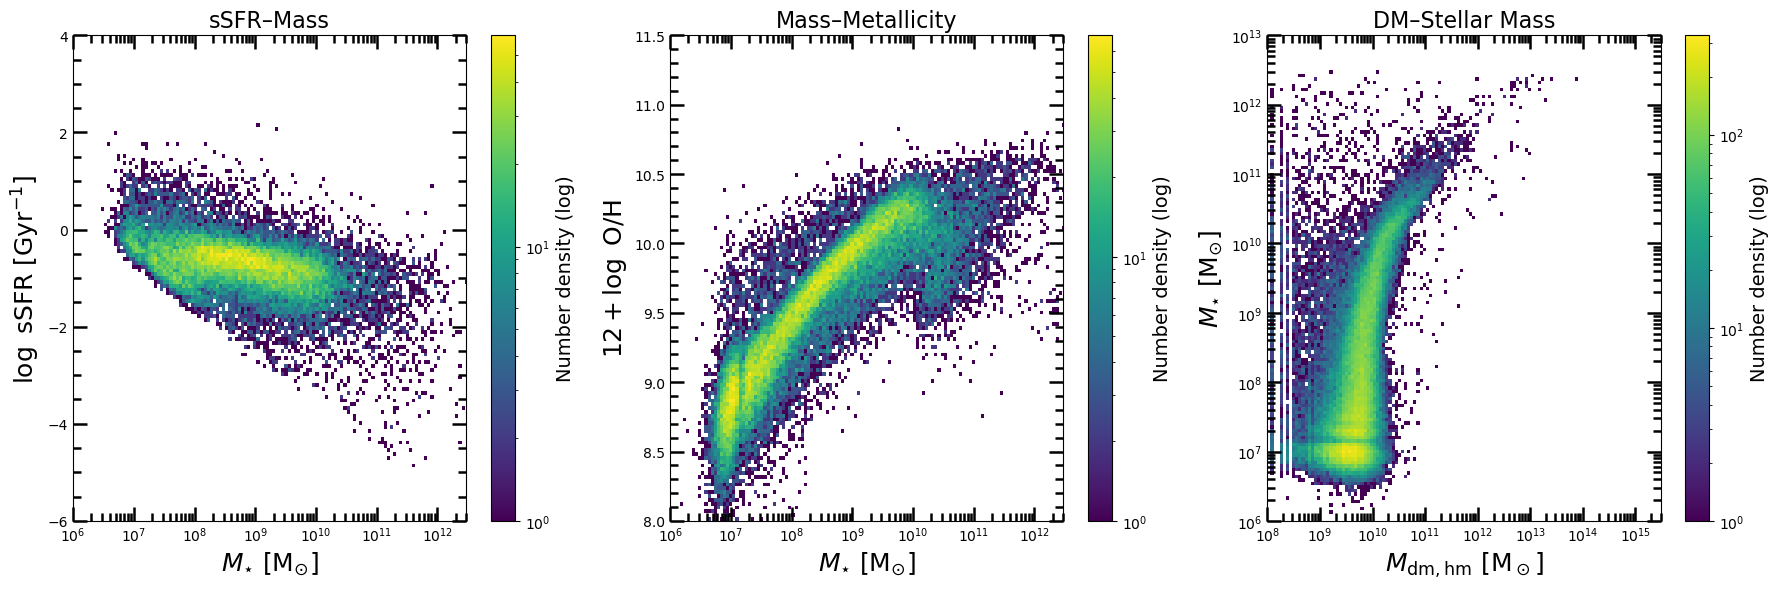

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# --- Random subsampling ---
# ---------------------------
frac = 0.1  # fraction of galaxies to plot (e.g. 0.1 = 10%)
np.random.seed(0)

mask = M_hm_star > 0
indices = np.where(mask)[0]
n_sample = max(1, int(frac * len(indices)))
sel_idx = np.random.choice(indices, n_sample, replace=False)

# sampled arrays
M_star = M_hm_star[sel_idx]
M_dm   = M_hm_dm[sel_idx]
SFR    = SFR_hm[sel_idx]
Metal  = Metal_O_H[sel_idx]

# ---------------------------
# --- Define log bins ---
# ---------------------------
bins_logMstar = np.logspace(6, 12.5, 128)   # for M_star
bins_logSFR   = np.linspace(-6, 4, 128)     # for log sSFR
bins_metal    = np.linspace(8, 11.5, 128)   # for metallicity
bins_logMdm   = np.logspace(8, 15.5, 128)   # for DM mass

# ---------------------------
# --- Figure setup ---
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- (1) sSFR vs M_star ---
x = M_star
y = np.log10(SFR / M_star) + 9  # sSFR in Gyr^-1
hb1 = axes[0].hist2d(
    x, y,
    bins=[bins_logMstar, bins_logSFR],
    norm='log'
)

axes[0].set_xscale("log")
axes[0].set_xlabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[0].set_ylabel(r'$\log$ sSFR $\mathrm{[Gyr^{-1}]}$', fontsize=18)
axes[0].set_xlim(1e6, 3e12)
axes[0].minorticks_on()
axes[0].tick_params('both', length=6, width=1.8, which='minor', direction='in', right=True, top=True)
axes[0].tick_params('both', length=10, width=1.8, which='major', direction='in', right=True, top=True)
axes[0].set_title("sSFR–Mass", fontsize=16)

# --- (2) Metallicity vs M_star ---
x = M_star
y = np.log10(Metal) + 12
hb2 = axes[1].hist2d(
    x, y,
    bins=[bins_logMstar, bins_metal],
    norm='log'
)

axes[1].set_xscale("log")
axes[1].set_xlabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[1].set_ylabel(r'$12 + \log$ O/H', fontsize=18)
axes[1].set_xlim(1e6, 3e12)
axes[1].set_ylim(8, 11.5)
axes[1].minorticks_on()
axes[1].tick_params('both', length=6, width=1.8, which='minor', direction='in', right=True, top=True)
axes[1].tick_params('both', length=10, width=1.8, which='major', direction='in', right=True, top=True)
axes[1].set_title("Mass–Metallicity", fontsize=16)

# --- (3) M_star vs M_dm ---
x = M_dm
y = M_star
hb3 = axes[2].hist2d(
    x, y,
    bins=[bins_logMdm, bins_logMstar],
    norm='log'
)

axes[2].set_xscale("log")
axes[2].set_yscale("log")
axes[2].set_xlabel(r'$M_{\mathrm{dm,hm}}$ [M$_\odot$]', fontsize=18)
axes[2].set_ylabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=18)
axes[2].set_xlim(1e8, 3e15)
axes[2].set_ylim(1e6, 1e13)
axes[2].axvline(1e6, color='black', linewidth=1.5)
axes[2].axvspan(1e4, 1e6, alpha=0.3, color='gray')
axes[2].minorticks_on()
axes[2].tick_params('both', length=6, width=1.8, which='minor', direction='in', right=True, top=True)
axes[2].tick_params('both', length=10, width=1.8, which='major', direction='in', right=True, top=True)
axes[2].set_title("DM–Stellar Mass", fontsize=16)

# --- Add colorbars ---
for ax, hb in zip(axes, [hb1, hb2, hb3]):
    cbar = plt.colorbar(hb[3], ax=ax)
    cbar.set_label('Number density (log)', fontsize=14)

plt.tight_layout()
plt.show()


# See the HR cluster catalogues 

In [8]:
import pandas as pd

# Path to your text file
filename = 'TNG-Cluster_Catalog.txt'

df = pd.read_csv(filename, delim_whitespace=True, comment='#')
origID = df.iloc[:, 0]
haloID = df.iloc[:, 1]
mhalo_200c = df.iloc[:, 2]
mhalo_500c = df.iloc[:, 3]
r200c = df.iloc[:, 4]
r500c = df.iloc[:, 5]
mstar_30kpc = df.iloc[:, 6]
mstar_100kpc = df.iloc[:, 7]
mhi_halo = df.iloc[:, 8]
mass_smbh = df.iloc[:, 9]
fgas_r500 = df.iloc[:, 10]
sfr_30pkpc = df.iloc[:, 11]
xray_ = df.iloc[:, 12]
szy_r500c = df.iloc[:, 13]
Bmag_uG_10kpc = df.iloc[:, 14]
ne_10kpc = df.iloc[:, 15]
temp_10kpc = df.iloc[:, 16]
zform = df.iloc[:, 17]
richness_95 = df.iloc[:, 18]
richness_100 = df.iloc[:, 19]
richness_105 = df.iloc[:, 20]
richness_110 = df.iloc[:, 21]
coolcore_flag = df.iloc[:, 22]
coolcore_tcool = df.iloc[:, 23]
coolcore_entropy = df.iloc[:, 24]
coolcore_ne = df.iloc[:, 25]
coolcore_ne_slope = df.iloc[:, 26]
coolcore_C_phys = df.iloc[:, 27]
coolcore_C_scaled = df.iloc[:, 28]
perseus_like_flag = df.iloc[:, 29]
peakoffset_xray_x = df.iloc[:, 30]
peakoffset_xray_y = df.iloc[:, 31]
peakoffset_xray_z = df.iloc[:, 32]
peakoffset_sz_x = df.iloc[:, 33]
peakoffset_sz_y = df.iloc[:, 34]
peakoffset_sz_z = df.iloc[:, 35]


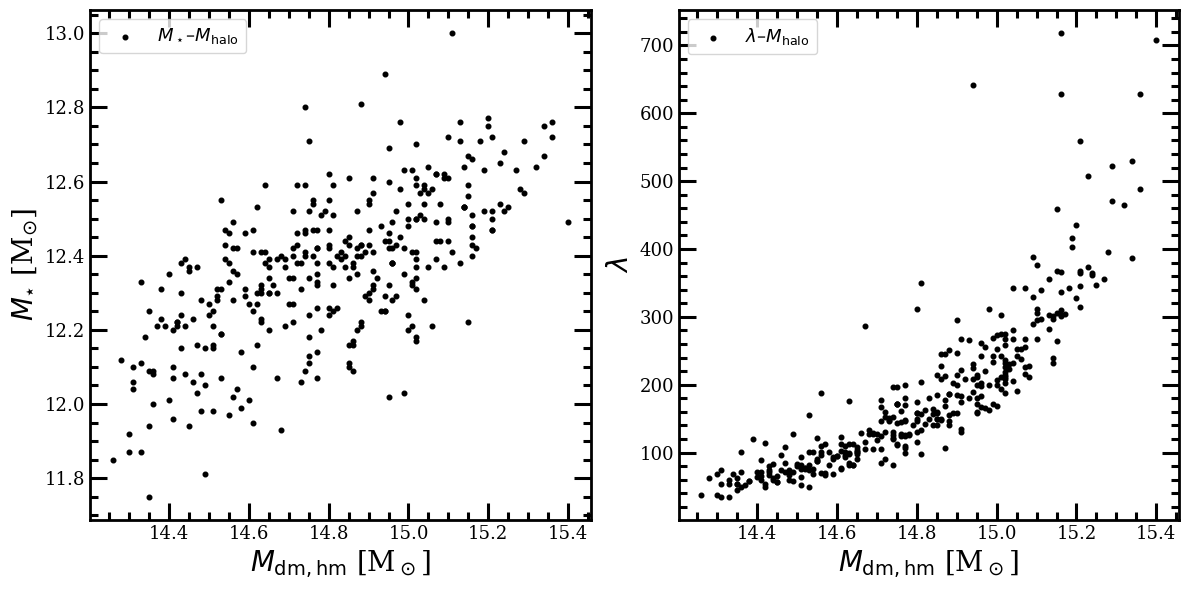

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# --- Plot settings ---
# ------------------------------------------
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# ------------------------------------------
# --- Figure setup (1×2) ---
# ------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# ------------------------------------------
# --- (1) Stellar mass vs halo mass ---
# ------------------------------------------
mask = mstar_100kpc > 0
ax1.scatter(
    mhalo_200c[mask],
    mstar_100kpc[mask],
    s=11,
    color='k',
    label=r'$M_\star$–$M_{\rm halo}$'
)

ax1.set_xlabel(r'$M_{\mathrm{dm,hm}}$ [M$_\odot$]', fontsize=20)
ax1.set_ylabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=20)
ax1.minorticks_on()
ax1.tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
ax1.tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)
ax1.legend(fontsize=13, loc='upper left')

# ------------------------------------------
# --- (2) Richness vs halo mass ---
# ------------------------------------------
ax2.scatter(
    mhalo_200c,
    richness_95,
    s=11,
    color='k',
    label=r'$\lambda$–$M_{\rm halo}$'
)

ax2.set_xlabel(r'$M_{\mathrm{dm,hm}}$ [M$_\odot$]', fontsize=20)
ax2.set_ylabel(r'$\lambda$', fontsize=20)
ax2.minorticks_on()
ax2.tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
ax2.tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)
ax2.legend(fontsize=13, loc='upper left')

# ------------------------------------------
# --- Layout & display ---
# ------------------------------------------
plt.tight_layout()
plt.show()


# Cross match the HR ids and Original Box

In [10]:
origID = df.iloc[:, 0]
haloID = df.iloc[:, 1]


####################
basePath_tngcluster = '/home/tnguser/sims.TNG/TNG-Cluster/output'
base_out = '/home/tnguser/TNGCluster'
snap_number=99

###############################
fields=['GroupFirstSub']
halos_tng50 = il.groupcat.loadHalos(basePath_tngcluster,snap_number,fields=fields)
subhalo_ids = halos_tng50[haloID]

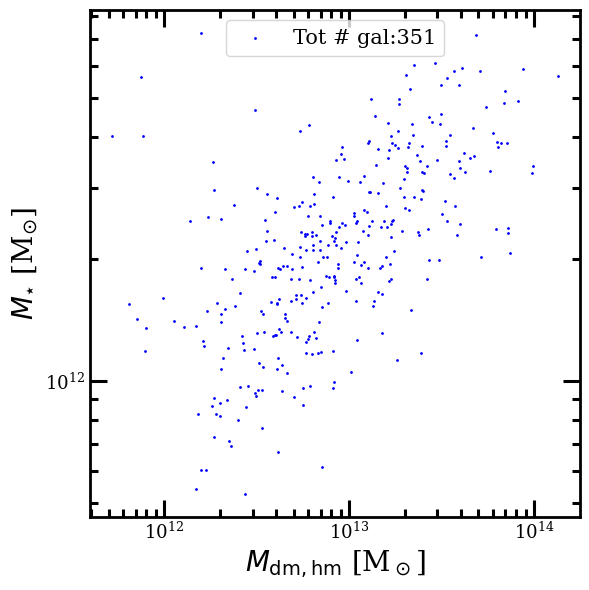

In [20]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['axes.linewidth'] = 2
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13

# --- single subplot ---
fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(
    M_hm_dm[subhalo_ids],  # y-axis now DM mass
    M_hm_star[subhalo_ids],
    label="Tot # gal:" + str(len(M_hm_star[subhalo_ids])),
    s=1,
    color='b'
)

# formatting
ax.set_ylabel(r'$M_{\mathrm{\star}}$ [M$_{\odot}$]', fontsize=20)
ax.set_xlabel(r'$M_{\mathrm{dm,hm}}$ [M$_\odot$]', fontsize=20)  # changed ylabel

ax.set_xscale("log")
ax.set_yscale("log")  # optional: log scale for DM mass
#ax.set_ylim(1e6,1e13)
#ax.set_xlim(1e8, 3e15)  # adjust limits for DM mass

ax.minorticks_on()
ax.tick_params('both', length=6, width=2.2, which='minor', direction='in', right=True, top=True)
ax.tick_params('both', length=12, width=2.2, which='major', direction='in', right=True, top=True)

ax.legend(fontsize=15, loc=9)

plt.tight_layout()
plt.show()


# Position of the central galaxies 

In [23]:
origID = df.iloc[:, 0]
haloID = df.iloc[:, 1]


####################
basePath_tng50 = '/home/tnguser/sims.TNG/TNG-Cluster/output'
base_out = '/home/tnguser/TNGCluster'
snap_number=99

###############################
fields=['GroupFirstSub']
halos_tng50 = il.groupcat.loadHalos(basePath_tng50,snap_number,fields=fields)


####################
basePath_tng50 = '/home/tnguser/sims.TNG/TNG-Cluster/output'
base_out = '/home/tnguser/TNGCluster'
snap_number=99

###########################
fields=['SubhaloCM','SubhaloMassInHalfRadType','SubhaloHalfmassRadType','SubhaloGasMetalFractionsHalfRad','SubhaloSFRinHalfRad']

subhalos_tng50 = il.groupcat.loadSubhalos(basePath_tngcluster,snap_number,fields=fields)


############### Pos_subhalos ########################
cm_x = np.array(subhalos_tng50['SubhaloCM'][subhalo_ids,0]) / 0.6774
cm_y = np.array(subhalos_tng50['SubhaloCM'][subhalo_ids,1]) / 0.6774
cm_z = np.array(subhalos_tng50['SubhaloCM'][subhalo_ids,2]) / 0.6774

############### M_subhalos ########################
M_hm_gas = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][subhalo_ids,0])*1e10 / 0.6774
M_hm_dm = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][subhalo_ids,1])*1e10 / 0.6774
M_hm_star = np.array(subhalos_tng50['SubhaloMassInHalfRadType'][subhalo_ids,4])*1e10 / 0.6774

################# Metallicity Gas ####################

H_hm_gas = np.array(subhalos_tng50['SubhaloGasMetalFractionsHalfRad'][subhalo_ids,0])
O_hm_gas = np.array(subhalos_tng50['SubhaloGasMetalFractionsHalfRad'][subhalo_ids,4])

############### r_hm ########################

r_hm_gas = np.array(subhalos_tng50['SubhaloHalfmassRadType'][subhalo_ids,0])/ 0.6774
r_hm_dm = np.array(subhalos_tng50['SubhaloHalfmassRadType'][subhalo_ids,1])/ 0.6774
r_hm_star = np.array(subhalos_tng50['SubhaloHalfmassRadType'][subhalo_ids,4])/ 0.6774

################ sSFR ######################

SFR_hm  = np.array(subhalos_tng50['SubhaloSFRinHalfRad'])[subhalo_ids]


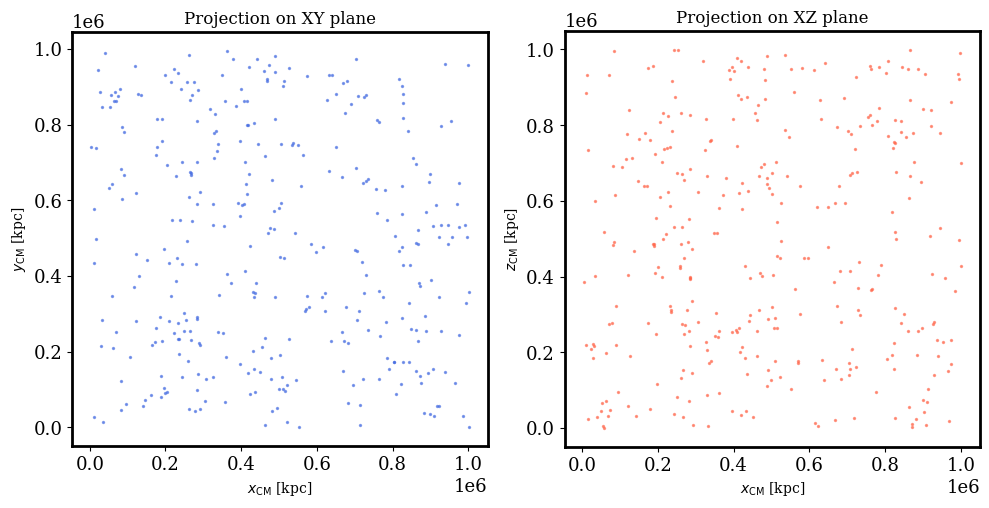

In [24]:
# ==========================
# Plotting
# ==========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# --- XY projection ---
ax1.scatter(cm_x, cm_y, s=2, color='royalblue', alpha=0.6)
ax1.set_xlabel(r'$x_{\rm CM}$ [kpc]')
ax1.set_ylabel(r'$y_{\rm CM}$ [kpc]')
ax1.set_title('Projection on XY plane')
ax1.set_aspect('equal', 'box')

# --- XZ projection ---
ax2.scatter(cm_x, cm_z, s=2, color='tomato', alpha=0.6)
ax2.set_xlabel(r'$x_{\rm CM}$ [kpc]')
ax2.set_ylabel(r'$z_{\rm CM}$ [kpc]')
ax2.set_title('Projection on XZ plane')
ax2.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()

# Track the Central galaxy Halo Mass evolution.

In [7]:
haloID[135]

12224103

Text(0, 0.5, 'Total Subhalo Mass')

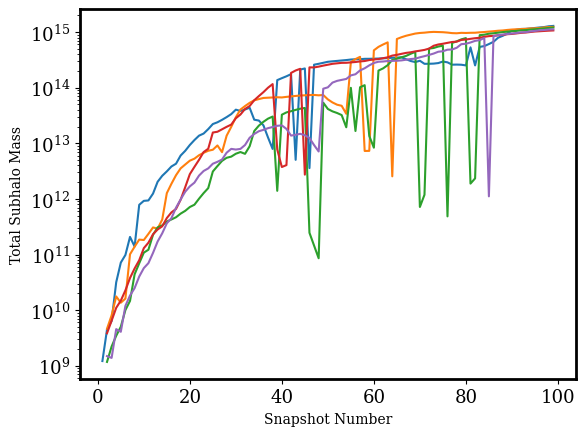

In [15]:
fields = ['SubhaloMass','SubfindID','SnapNum']
start = 20
for i in range(start,start+5):
    tree = il.sublink.loadTree(basePath_tngcluster,99,subhalo_ids[i],fields=fields,onlyMPB=True)
    plt.plot(tree['SnapNum'],tree['SubhaloMass']*1e10,'-')
plt.yscale('log')
plt.xlabel('Snapshot Number')
plt.ylabel('Total Subhalo Mass')